In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tqdm 
import os

In [216]:
df = pd.read_csv("/Users/ziadsamer/Documents/RotRate/data/brainrot.csv")

In [217]:
df.head()

,student_id,country,development_level,poverty_rate_percent,internet_infrastructure_index,average_internet_speed_mbps,age,gender,urban_rural,family_income_level,...,ads_viewed_per_day,ads_clicked_per_week,impulse_purchase_score,digital_spending_per_month,cyberbullying_exposure,adult_content_exposure,digital_addiction_score,wellbeing_index,academic_risk_score,financial_risk_score
0,1,Qatar,Developing,16.30,54.93,27.19,21,Male,Rural,High,...,38.699484,3.119569,3.681066,79.508194,No,No,8.179932,66.662166,0.0,26.516722
1,2,USA,Developed,8.75,94.39,85.34,25,Male,Urban,Middle,...,157.400429,18.358090,6.538867,73.452464,No,Yes,22.073122,43.892278,0.0,39.257741
2,3,Mexico,Developing,23.64,47.24,73.55,18,Female,Urban,Low,...,79.603536,11.758299,5.150660,35.753069,No,No,12.591830,65.484625,0.0,47.542155
3,4,Canada,Developed,14.51,90.50,188.19,25,Male,Urban,Middle,...,69.318324,7.906197,3.195383,47.607487,No,Yes,8.008238,57.909392,0.0,23.436122
4,5,Sri Lanka,Underdeveloped,62.28,36.84,11.02,15,Other,Rural,Middle,...,144.019899,19.427839,7.180234,82.941313,No,No,21.551334,53.686356,0.0,47.308493


In [218]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 48 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   student_id                      500000 non-null  int64  
 1   country                         500000 non-null  str    
 2   development_level               500000 non-null  str    
 3   poverty_rate_percent            500000 non-null  float64
 4   internet_infrastructure_index   500000 non-null  float64
 5   average_internet_speed_mbps     500000 non-null  float64
 6   age                             500000 non-null  int64  
 7   gender                          500000 non-null  str    
 8   urban_rural                     500000 non-null  str    
 9   family_income_level             500000 non-null  str    
 10  device_access                   500000 non-null  str    
 11  internet_access_hours           500000 non-null  float64
 12  education_level            

In [219]:
working_df = df.copy()

# Data Exploration

In [220]:
df.head()

,student_id,country,development_level,poverty_rate_percent,internet_infrastructure_index,average_internet_speed_mbps,age,gender,urban_rural,family_income_level,...,ads_viewed_per_day,ads_clicked_per_week,impulse_purchase_score,digital_spending_per_month,cyberbullying_exposure,adult_content_exposure,digital_addiction_score,wellbeing_index,academic_risk_score,financial_risk_score
0,1,Qatar,Developing,16.30,54.93,27.19,21,Male,Rural,High,...,38.699484,3.119569,3.681066,79.508194,No,No,8.179932,66.662166,0.0,26.516722
1,2,USA,Developed,8.75,94.39,85.34,25,Male,Urban,Middle,...,157.400429,18.358090,6.538867,73.452464,No,Yes,22.073122,43.892278,0.0,39.257741
2,3,Mexico,Developing,23.64,47.24,73.55,18,Female,Urban,Low,...,79.603536,11.758299,5.150660,35.753069,No,No,12.591830,65.484625,0.0,47.542155
3,4,Canada,Developed,14.51,90.50,188.19,25,Male,Urban,Middle,...,69.318324,7.906197,3.195383,47.607487,No,Yes,8.008238,57.909392,0.0,23.436122
4,5,Sri Lanka,Underdeveloped,62.28,36.84,11.02,15,Other,Rural,Middle,...,144.019899,19.427839,7.180234,82.941313,No,No,21.551334,53.686356,0.0,47.308493


In [221]:
working_df.drop(columns=['academic_risk_score', 'financial_risk_score', 'wellbeing_index'], inplace=True)

# Data Validation & Cleaning

## Accuracy

## Relationships profile

In [222]:
df.groupby("country").agg({
    "poverty_rate_percent": ['mean']
}).reset_index().head()

,country,poverty_rate_percent
,,mean
0,Argentina,18.99
1,Australia,13.66
2,Bangladesh,37.93
3,Bolivia,44.35
4,Brazil,25.50


In [223]:
df.groupby("country").agg({
    "internet_infrastructure_index": ['mean']
}).reset_index().head(10)

,country,internet_infrastructure_index
,,mean
0,Argentina,68.14
1,Australia,78.92
2,Bangladesh,39.13
3,Bolivia,35.68
4,Brazil,69.07
5,Cambodia,43.13
6,Canada,90.50
7,Chile,47.22
8,China,61.28


### Key Findings
- `country` / `poverty_rate_percent` / `development_level` / `internet_infrastructure_index` / `average_internet_speed_mbps` are all related to the same country
- `brain_rot_level` is highly related to brain rot index.


### Actions
- drop `country` and `poverty_rate_percent`
- encode `development_level` ordinal encoding
- encode `internet_infrastructure_index` or `average_internet_speed_mbps` as ordinal encoding and drop the second
- drop `brain_rot_level`

In [224]:
working_df.drop(columns=['late_night_score', 'country', 'poverty_rate_percent', 
                         'internet_infrastructure_index', 'brain_rot_level',
                         'attention_span_minutes', 'productivity_score', 
                         'impulse_purchase_score', 'digital_addiction_score', 'academic_motivation'], inplace=True)

In [225]:
working_df.head()

,student_id,development_level,average_internet_speed_mbps,age,gender,urban_rural,family_income_level,device_access,internet_access_hours,education_level,...,class_attendance_rate,sleep_hours,stress_level,anxiety_score,depression_score,ads_viewed_per_day,ads_clicked_per_week,digital_spending_per_month,cyberbullying_exposure,adult_content_exposure
0,1,Developing,27.19,21,Male,Rural,High,Smartphone,5.239520,Graduate,...,95.482386,7.139022,4.261971,3.192920,1.409102,38.699484,3.119569,79.508194,No,No
1,2,Developed,85.34,25,Male,Urban,Middle,Smartphone,6.262420,Diploma,...,86.616985,4.000000,8.213495,8.064935,7.695221,157.400429,18.358090,73.452464,No,Yes
2,3,Developing,73.55,18,Female,Urban,Low,Smartphone,3.437670,Dropout,...,89.628198,6.809331,2.931317,1.719159,1.000000,79.603536,11.758299,35.753069,No,No
3,4,Developed,188.19,25,Male,Urban,Middle,Laptop,4.203739,PhD,...,93.385581,7.537228,4.356061,4.860839,1.755233,69.318324,7.906197,47.607487,No,Yes
4,5,Underdeveloped,11.02,15,Other,Rural,Middle,Smartphone,5.419135,School,...,92.618321,5.522188,6.578642,6.025506,3.678578,144.019899,19.427839,82.941313,No,No


In [226]:
working_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 35 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   student_id                      500000 non-null  int64  
 1   development_level               500000 non-null  str    
 2   average_internet_speed_mbps     500000 non-null  float64
 3   age                             500000 non-null  int64  
 4   gender                          500000 non-null  str    
 5   urban_rural                     500000 non-null  str    
 6   family_income_level             500000 non-null  str    
 7   device_access                   500000 non-null  str    
 8   internet_access_hours           500000 non-null  float64
 9   education_level                 500000 non-null  str    
 10  field_of_study                  252651 non-null  str    
 11  online_learning_hours           500000 non-null  float64
 12  social_media_hours         

## Consistency

## Completeness

In [227]:
working_df.isnull().sum()

student_id                             0
development_level                      0
average_internet_speed_mbps            0
age                                    0
gender                                 0
urban_rural                            0
family_income_level                    0
device_access                          0
internet_access_hours                  0
education_level                        0
field_of_study                    247349
online_learning_hours                  0
social_media_hours                     0
sessions_per_day                       0
average_session_length_minutes         0
late_night_usage                       0
education_content_hours                0
short_video_hours                      0
entertainment_content_hours            0
news_content_hours                     0
likes_given_per_day                    0
comments_written_per_day               0
posts_created_per_week                 0
brain_rot_index                        0
study_hours_per_

In [228]:
len(working_df.dropna()) / len(working_df) * 100

50.5302

In [229]:
working_df.drop(columns=['field_of_study'], inplace=True)

### Key Findings
- field_of_study has nulls
- brain_rot_level has nulls

## Data Uniqueness

In [230]:
for col in working_df.columns:
    if working_df.duplicated(subset=[col]).sum() > 0:
        print(col)

development_level
average_internet_speed_mbps
age
gender
urban_rural
family_income_level
device_access
internet_access_hours
education_level
online_learning_hours
social_media_hours
sessions_per_day
average_session_length_minutes
late_night_usage
education_content_hours
short_video_hours
entertainment_content_hours
news_content_hours
posts_created_per_week
brain_rot_index
class_attendance_rate
sleep_hours
stress_level
anxiety_score
depression_score
ads_viewed_per_day
ads_clicked_per_week
digital_spending_per_month
cyberbullying_exposure
adult_content_exposure


## Outliers Handling

In [231]:
from scipy.stats import skew, kurtosis

In [232]:
numerical_df = working_df.select_dtypes(include=['int64', 'float64']).copy()

In [233]:
numerical_df.describe()

,student_id,average_internet_speed_mbps,age,internet_access_hours,online_learning_hours,social_media_hours,sessions_per_day,average_session_length_minutes,education_content_hours,short_video_hours,...,brain_rot_index,study_hours_per_week,class_attendance_rate,sleep_hours,stress_level,anxiety_score,depression_score,ads_viewed_per_day,ads_clicked_per_week,digital_spending_per_month
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,...,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,250000.500000,72.663154,19.996474,5.013043,6.318560,3.360787,9.901511,38.614799,0.547448,1.512743,...,19.027812,22.982425,90.770633,5.991174,4.851059,4.861232,5.085747,97.020675,12.643289,59.888421
std,144337.711635,65.315300,3.161021,1.581660,1.848903,1.292885,3.382135,13.523370,0.342649,0.660519,...,9.073310,5.280921,6.097074,0.971632,1.489437,1.771165,2.073001,33.335935,4.469668,29.120812
min,1.000000,5.740000,15.000000,0.500000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,...,0.000000,2.000000,63.027961,4.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,125000.750000,20.420000,17.000000,3.911805,5.080963,2.457786,7.547886,29.197459,0.297473,1.039786,...,12.573607,19.452559,86.607702,5.314924,3.820139,3.628933,3.612049,73.817802,9.557982,38.202779
50%,250000.500000,45.630000,20.000000,5.012280,6.354281,3.290051,9.744129,37.985036,0.473294,1.438173,...,18.559927,23.120482,91.061650,6.019641,4.818971,4.837090,5.044635,95.385942,12.492320,55.094270
75%,375000.250000,107.410000,23.000000,6.112144,7.585492,4.196469,12.097976,47.391041,0.714748,1.910393,...,25.090031,26.641517,95.465249,6.670804,5.858835,6.063411,6.512151,118.644706,15.577609,76.732047
max,500000.000000,238.050000,25.000000,11.273316,13.530034,9.000000,26.032059,90.000000,3.516415,5.255491,...,59.003904,43.321999,100.000000,9.000000,10.000000,10.000000,10.000000,256.626877,33.933309,198.609505


In [234]:
profile = pd.DataFrame({
    'Min': numerical_df.min(),
    'Max': numerical_df.max(),
    'Mean': numerical_df.mean(),
    'Median': numerical_df.median(),
    'Std': numerical_df.std(),
    'Skewness': skew(numerical_df),
    'Kurtosis': kurtosis(numerical_df),
    'Unique': numerical_df.nunique()
})

In [235]:
profile[(np.abs(profile['Mean'] / profile['Median']) < profile['Std'] / 2) & (np.abs(profile['Skewness']) < 1)]

,Min,Max,Mean,Median,Std,Skewness,Kurtosis,Unique
student_id,1.000000,500000.000000,250000.500000,250000.500000,144337.711635,8.717697e-17,-1.200000,500000
age,15.000000,25.000000,19.996474,20.000000,3.161021,2.290637e-03,-1.219671,11
sessions_per_day,1.000000,26.032059,9.901511,9.744129,3.382135,2.569025e-01,0.031783,499358
average_session_length_minutes,3.000000,90.000000,38.614799,37.985036,13.523370,2.564339e-01,0.016761,499171
likes_given_per_day,4.014035,239.874685,69.305863,65.278381,29.823112,6.879423e-01,0.461018,500000
comments_written_per_day,0.200967,29.008121,6.924658,6.284939,3.833702,7.951463e-01,0.372467,500000
posts_created_per_week,0.000000,17.021500,4.203488,3.814943,2.245674,8.461497e-01,0.650975,499247
brain_rot_index,0.000000,59.003904,19.027812,18.559927,9.073310,2.477769e-01,-0.225965,493739
study_hours_per_week,2.000000,43.321999,22.982425,23.120482,5.280921,-1.138646e-01,-0.140355,500000
class_attendance_rate,63.027961,100.000000,90.770633,91.061650,6.097074,-3.729405e-01,-0.345898,457600


In [236]:
normal_list = profile[(np.abs(profile['Mean'] / profile['Median']) < profile['Std'] / 2) & (np.abs(profile['Skewness']) < 1)].index.tolist()

In [237]:
skewed_list = list(set(numerical_df.columns.tolist()) - set(normal_list))

In [238]:
skewed_list

['sleep_hours',
 'average_internet_speed_mbps',
 'internet_access_hours',
 'online_learning_hours',
 'entertainment_content_hours',
 'education_content_hours',
 'stress_level',
 'anxiety_score',
 'short_video_hours',
 'news_content_hours',
 'social_media_hours']

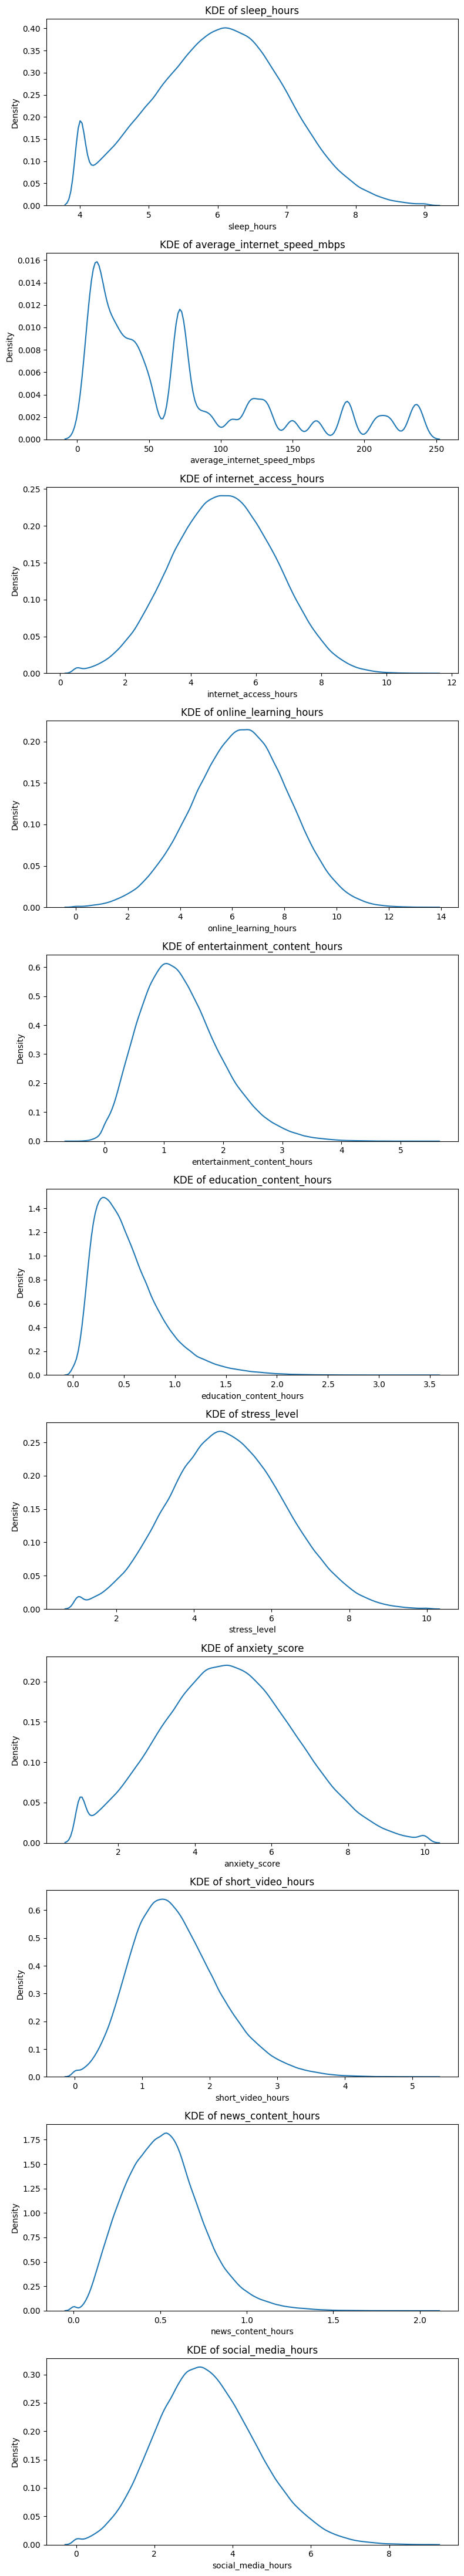

In [239]:
fig, axes = plt.subplots(len(skewed_list), 1, figsize=(8, 4 * len(skewed_list)))

if len(skewed_list) == 1:
    axes = [axes]

for i, col in enumerate(skewed_list):
    sns.kdeplot(data=numerical_df, x=col, ax=axes[i])
    axes[i].set_title(f"KDE of {col}")

plt.tight_layout()
plt.show()

In [240]:
normal_list

['student_id',
 'age',
 'sessions_per_day',
 'average_session_length_minutes',
 'likes_given_per_day',
 'comments_written_per_day',
 'posts_created_per_week',
 'brain_rot_index',
 'study_hours_per_week',
 'class_attendance_rate',
 'depression_score',
 'ads_viewed_per_day',
 'ads_clicked_per_week',
 'digital_spending_per_month']

In [241]:
for col in ['average_internet_speed_mbps', 'education_content_hours', 'entertainment_content_hours', 'news_content_hours', 'short_video_hours', 'social_media_hours' ]:
    working_df[col] = working_df[col].apply(lambda x: np.log(x + 0.001))

/var/folders/p6/82pzwvfj08b5bktj5wbwqwh00000gn/T/ipykernel_31480/1026093193.py:2: RuntimeWarning: invalid value encountered in log
  working_df[col] = working_df[col].apply(lambda x: np.log(x + 0.001))


## Key takeaways
- `age`, `sessions_per_day`, `average_session_length_minutes`, `likes_given_per_day`, `comments_written_per_day`, `posts_created_per_week`, `study_hours_per_week`, `class_attendance_rate`, `depression_score`, `ads_viewed_per_day`, `ads_clicked_per_week`, `digital_spending_per_month`  follows unifrom distribtion but needs standardization
- `average_internet_speed_mbps`, `education_content_hours`, `entertainment_content_hours`, `news_content_hours`, `short_video_hours`, `social_media_hours`    needs sqrt transformation followed by standardization

# Feature Engineering

## Feature Encoding

In [242]:
cat_df = working_df.select_dtypes(include=['object']).copy()

/var/folders/p6/82pzwvfj08b5bktj5wbwqwh00000gn/T/ipykernel_31480/840731593.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_df = working_df.select_dtypes(include=['object']).copy()


In [243]:
cat_df.columns

Index(['development_level', 'gender', 'urban_rural', 'family_income_level',
       'device_access', 'education_level', 'late_night_usage',
       'cyberbullying_exposure', 'adult_content_exposure'],
      dtype='str')

In [244]:
def get_counts(df, col):
    print(df[col].value_counts())


In [245]:
get_counts(cat_df, 'device_access')

device_access
Smartphone       302885
Both              74609
Shared Device     67162
Laptop            55344
Name: count, dtype: int64


In [246]:
get_counts(cat_df, 'cyberbullying_exposure')

cyberbullying_exposure
No     438002
Yes     61998
Name: count, dtype: int64


In [247]:
get_counts(cat_df, 'gender')

gender
Female    245241
Male      244803
Other       9956
Name: count, dtype: int64


In [248]:
working_df['gender'] = working_df['gender'].map({
    'Female': 0,
    'Male': 1,
    'Other': 2
})

working_df['urban_rural'] = working_df['urban_rural'].map({
    'Rural': 0,
    'Urban': 1
})

working_df['cyberbullying_exposure'] = working_df['cyberbullying_exposure'].map({
    'No': 0,
    'Yes': 1
})

working_df['adult_content_exposure'] = working_df['adult_content_exposure'].map({
    'No': 0,
    'Yes': 1
})

In [249]:
working_df['development_level'] = working_df['development_level'].map({
    'Developing': 2,
    'Developed': 1,
    'Underdeveloped': 0
})

working_df['family_income_level'] = working_df['family_income_level'].map({
    'High': 2,
    'Middle': 1,
    'Low': 0
})

working_df['education_level'] = working_df['education_level'].map({
    'PhD': 5,
    'Postgraduate': 4,
    'Graduate': 3,
    'Diploma': 2,
    'School': 1,
    'Dropout': 0
})

working_df['late_night_usage'] = working_df['late_night_usage'].map({
    'Never': 0,
    'Sometimes': 1,
    'Often': 2,
    'Always': 3
})

In [251]:
working_df.dropna(inplace=True)

In [253]:
working_df = pd.get_dummies(working_df, columns=['device_access'])

In [254]:
working_df.info()

<class 'pandas.DataFrame'>
Index: 497980 entries, 0 to 499999
Data columns (total 37 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   student_id                      497980 non-null  int64  
 1   development_level               497980 non-null  int64  
 2   average_internet_speed_mbps     497980 non-null  float64
 3   age                             497980 non-null  int64  
 4   gender                          497980 non-null  int64  
 5   urban_rural                     497980 non-null  int64  
 6   family_income_level             497980 non-null  int64  
 7   internet_access_hours           497980 non-null  float64
 8   education_level                 497980 non-null  int64  
 9   online_learning_hours           497980 non-null  float64
 10  social_media_hours              497980 non-null  float64
 11  sessions_per_day                497980 non-null  float64
 12  average_session_length_minutes  

## Actions
- encode `gender` ```json {male : 1, female: 0}``` **Binary Encoding**
- encode `urban_rural` ```json{Urban: 1, Rural: 0}``` **Binary Encoding**
- encode `cyberbullying_exposure`, `adult_content_exposure` ```json {"No" : 0, "Yes": 1}``` **Binary Encoding**
- encode `development_level`, `family_income_level`, `education_level`, `late_night_usage` **Label encoding**
- encode `device_access` **One Hot Encoding**

## Correlation Analysis

In [264]:
corr = working_df.corr()
vals = corr.values.copy()
np.fill_diagonal(vals, np.nan)
corr_no_diag = pd.DataFrame(vals, index=corr.index, columns=corr.columns)

most_corr = corr_no_diag.idxmax()
most_corr_values = corr_no_diag.max()

result = pd.DataFrame({
    'most_correlated_with': most_corr,
    'correlation': most_corr_values
})

In [265]:
result = result[result['correlation'] > 0.7].sort_values(by='correlation', ascending=False)

In [266]:
result

,most_correlated_with,correlation
sessions_per_day,average_session_length_minutes,0.912651
average_session_length_minutes,sessions_per_day,0.912651
ads_clicked_per_week,sessions_per_day,0.843831
stress_level,anxiety_score,0.829712
anxiety_score,stress_level,0.829712
likes_given_per_day,sessions_per_day,0.794238
social_media_hours,entertainment_content_hours,0.793606
entertainment_content_hours,social_media_hours,0.793606
family_income_level,digital_spending_per_month,0.770285
digital_spending_per_month,family_income_level,0.770285


In [263]:
working_df.drop(columns=['short_video_hours', 'ads_viewed_per_day'], inplace=True)

## Key takeaways
- drop `short_video_hours`, `ads_viewed_per_day` as they are highly correlated